In [2]:
# import the case 2 data
import pandas as pd

DATA_LOC = "../data/HR_data.csv"
ID_STR = "Individual"

raw_data = pd.read_csv(DATA_LOC)

# Split data into features and target; features would be the columns with 'HR_TD_', 'TEMP_TD', and 'EDA_TD' (about 48 columns);
# The rest goes to target variable Y
X = raw_data.filter(regex='HR_TD_|TEMP_TD|EDA_TD_|Individual')
Y = raw_data.drop(columns=X.columns)

X.head()

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,Individual
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,1.345997,-1.379434,-0.000144,0.000138,0.000010,1.036040e-05,11,2.522727,2.075000,1
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,0.887010,0.854067,-0.000146,0.000165,0.000009,7.714503e-06,15,2.214286,2.192308,1
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,0.205817,0.480581,-0.000112,0.000132,0.000002,1.799914e-06,10,1.972222,2.111111,1
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,2.488339,1.246665,-0.000455,0.000481,-0.000001,-1.355151e-07,12,1.886364,1.805556,1
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,1.196508,1.592099,-0.000420,0.000334,0.000014,1.267198e-05,20,1.812500,1.926471,1


In [3]:
raw_data[ID_STR].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26])

In [4]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

# We want to scale the features (X) but grouped by the individuals (ID column).
# This is because we want to preserve the relative differences between the features for each individual, while also ensuring that the features are on a similar scale across all individuals.
# The target are emotional states, so if we globally did it, a person with higher baseline heart rate would have higher values for all features, which might not be ideal.
scaler = StandardScaler()

X_scaled_individual = X.copy().groupby(raw_data[ID_STR]).transform(lambda x: scaler.fit_transform(x.to_frame())[:, 0] if x.ndim == 1 else scaler.fit_transform(x))
import numpy as np
X_scaled_individual = X_scaled_individual.fillna(0)


For k=2 (Global Avg: 0.144):
  Cluster 0: Max Silhouette = 0.339 -> PASS
  --> k=2 SATISFIES the rule!
  Cluster 1: Max Silhouette = 0.223 -> PASS
  --> k=2 SATISFIES the rule!

For k=3 (Global Avg: 0.070):
  Cluster 0: Max Silhouette = 0.217 -> PASS
  --> k=3 SATISFIES the rule!
  Cluster 1: Max Silhouette = 0.150 -> PASS
  --> k=3 SATISFIES the rule!
  Cluster 2: Max Silhouette = 0.184 -> PASS
  --> k=3 SATISFIES the rule!

For k=4 (Global Avg: 0.078):
  Cluster 0: Max Silhouette = 0.186 -> PASS
  --> k=4 SATISFIES the rule!
  Cluster 1: Max Silhouette = 0.155 -> PASS
  --> k=4 SATISFIES the rule!
  Cluster 2: Max Silhouette = 0.169 -> PASS
  --> k=4 SATISFIES the rule!
  Cluster 3: Max Silhouette = 0.269 -> PASS
  --> k=4 SATISFIES the rule!

For k=5 (Global Avg: 0.062):
  Cluster 0: Max Silhouette = 0.223 -> PASS
  --> k=5 SATISFIES the rule!
  Cluster 1: Max Silhouette = 0.192 -> PASS
  --> k=5 SATISFIES the rule!
  Cluster 2: Max Silhouette = 0.156 -> PASS
  --> k=5 SATISFIES th

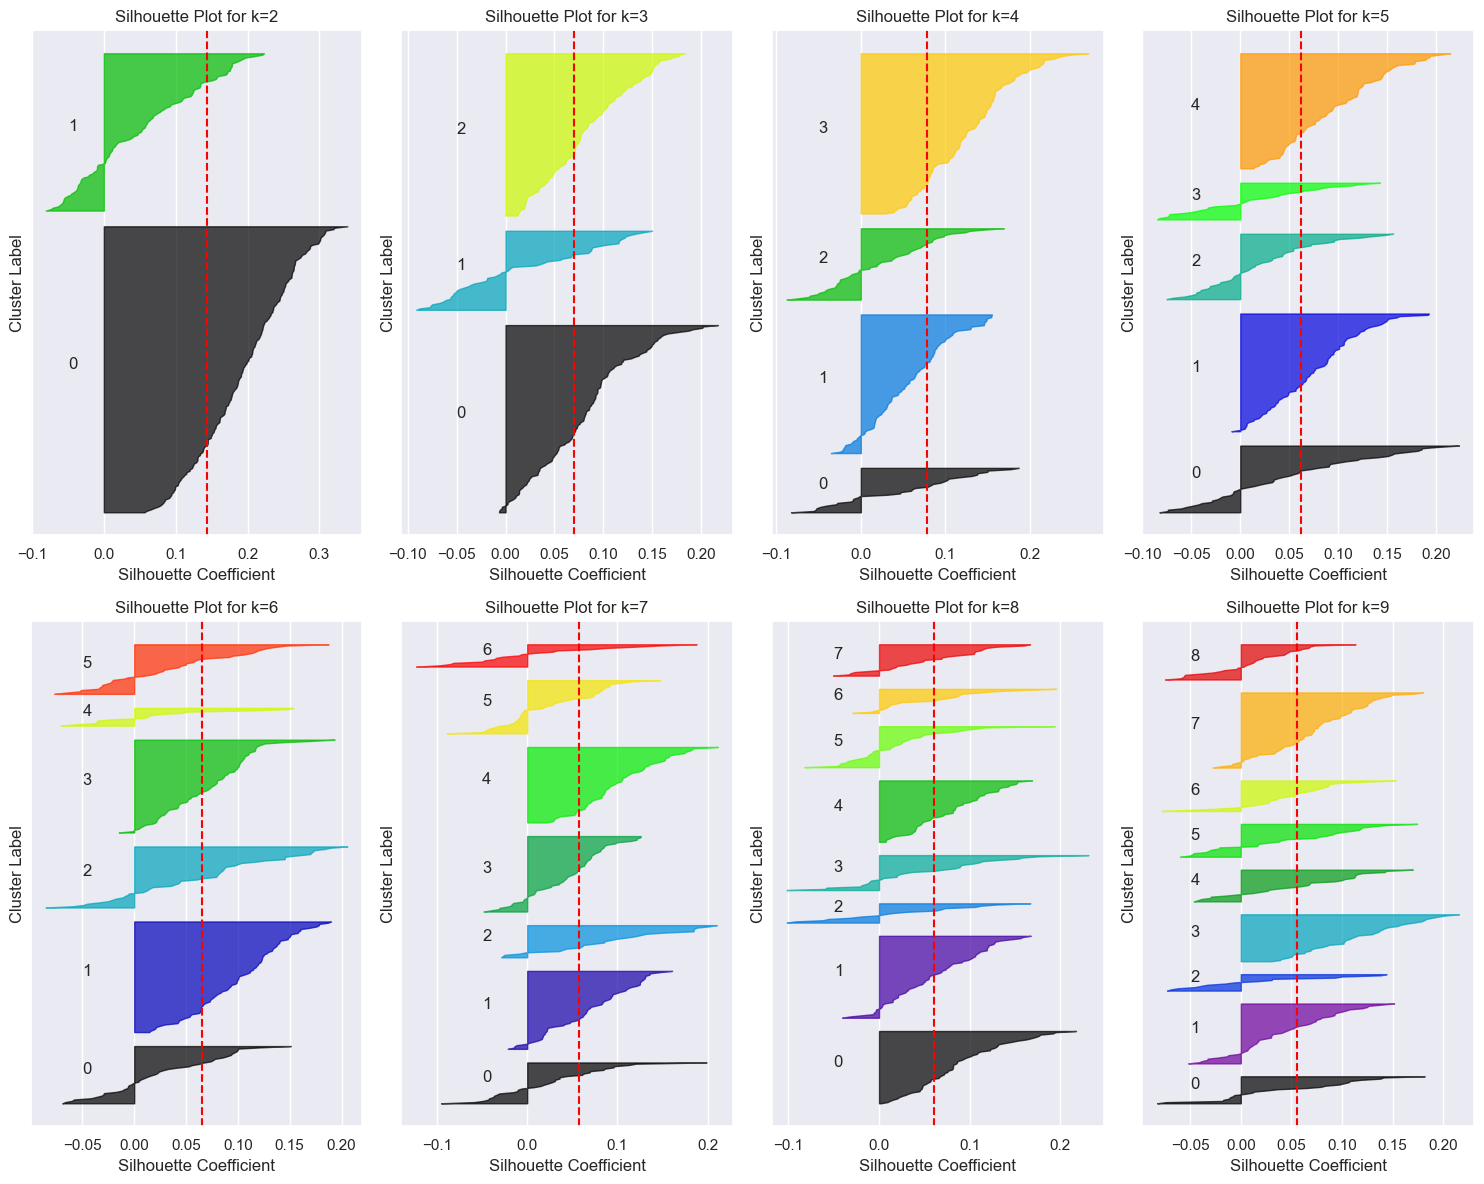

In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme()

# Variables (and their ranges)
k_range = range(2, 10) # Testing K from 2 to 10 (shared K now)

kmeans_silhouette_scores = []

#PLT plot stuff
fig, axes = plt.subplots(2, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, k in enumerate(k_range):
    ax = axes[idx]
    # ------------------
    # K-MEANS CLUSTERING
    # ------------------
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled_individual)

    global_avg_score = silhouette_score(X_scaled_individual, cluster_labels)
    sample_scores = silhouette_samples(X_scaled_individual, cluster_labels)

    kmeans_silhouette_scores.append(global_avg_score)

    all_clusters_valid = True  # Variable for tracking if all clusters have valid silhouette scores
    print(f"\nFor k={k} (Global Avg: {global_avg_score:.3f}):")
    
    y_lower = 10  # Plot spacing reasons

    for i in range(k):
        ith_cluster_scores = sample_scores[cluster_labels == i]
        ith_cluster_scores.sort()

        # This is where we check if the cluster has at least one observation with a silhouette score above the global average
        max_in_cluster = ith_cluster_scores.max()
        has_obs_above_avg = max_in_cluster > global_avg_score
        
        print(f"  Cluster {i}: Max Silhouette = {max_in_cluster:.3f} -> {'PASS' if has_obs_above_avg else 'FAIL'}")
        if not has_obs_above_avg:
            all_clusters_valid = False
        
        size_cluster_i = ith_cluster_scores.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_scores,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # move it up now (seperate the clusters for visual pleasure)
    
        if all_clusters_valid:  # We check which 'k' satisfies the rule of being above the average.
            print(f"  --> k={k} SATISFIES the rule!")
    
    # Plot stuff
    ax.set_title(f"Silhouette Plot for k={k}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=global_avg_score, color="red", linestyle="--") # The Average Line
    ax.set_yticks([])  # Clear the y-axis labels

plt.tight_layout()
# plt.savefig('silhouette_scores_kmeans.png')
plt.show()


  Cluster 0: Max Silhouette = 0.342 -> PASS
  Cluster 1: Max Silhouette = 0.225 -> PASS
  --> k=2 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.146 -> PASS
  Cluster 1: Max Silhouette = 0.314 -> PASS
  Cluster 2: Max Silhouette = 0.209 -> PASS
  --> k=3 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.184 -> PASS
  Cluster 1: Max Silhouette = 0.153 -> PASS
  Cluster 2: Max Silhouette = 0.168 -> PASS
  Cluster 3: Max Silhouette = 0.274 -> PASS
  --> k=4 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.163 -> PASS
  Cluster 1: Max Silhouette = 0.124 -> PASS
  Cluster 2: Max Silhouette = 0.220 -> PASS
  Cluster 3: Max Silhouette = 0.244 -> PASS
  Cluster 4: Max Silhouette = 0.159 -> PASS
  --> k=5 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.167 -> PASS
  Cluster 1: Max Silhouette = 0.177 -> PASS
  Cluster 2: Max Silhouette = 0.164 -> PASS
  Cluster 3: Max Silhouette = 0.147 -> PASS
  Cluster 4: Max Silhouette = 0.242 -> PASS
  Cluster 5: Max Silhouette = 0.128 -> PASS


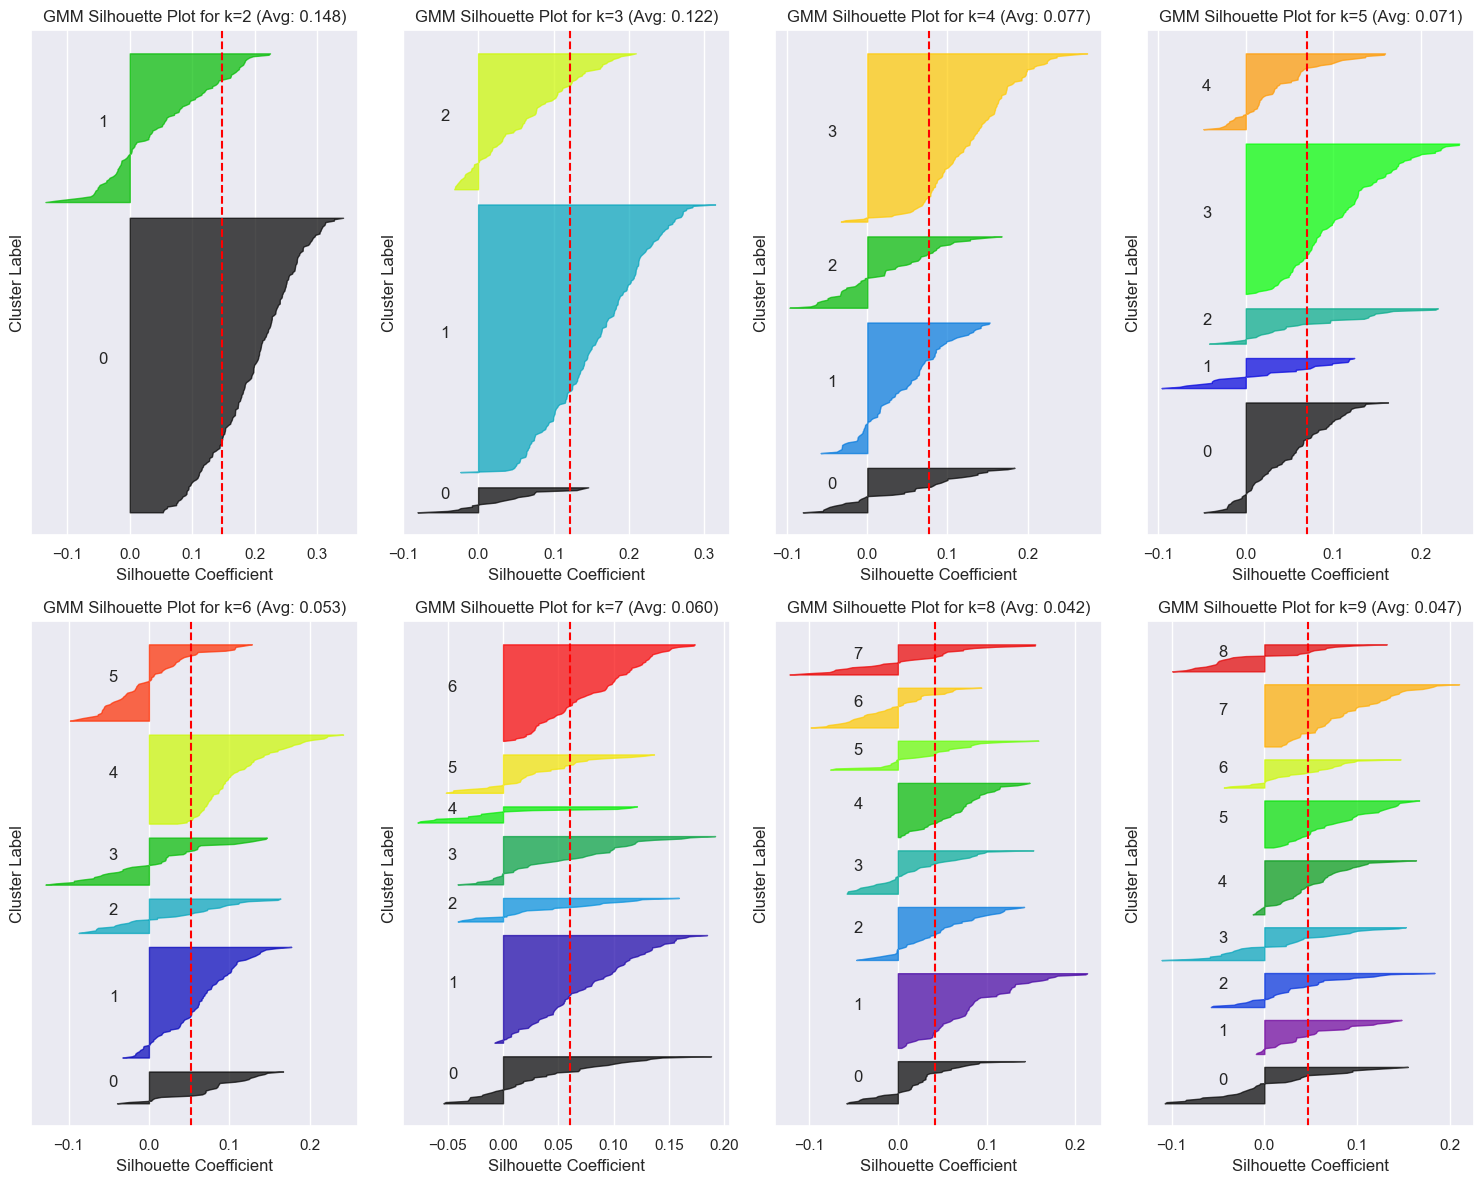

In [6]:
# Repeating for GMM
fig, axes = plt.subplots(2, 4, figsize=(15, 12))
axes = axes.flatten()

valid_ks_gmm = []
gmm_silhouette_scores = []
gmm_labels = []
gmm_scores = []
gmm_aic = []
gmm_bic = []

for idx, k in enumerate(k_range):
    ax = axes[idx]

    gmm = GaussianMixture(n_components=k, covariance_type='full',n_init=20, max_iter=1000, random_state=42, reg_covar=1e-6,)
    
    cluster_labels = gmm.fit_predict(X_scaled_individual)
    cluster_scores = gmm.score(X_scaled_individual)
    cluster_aic = gmm.aic(X_scaled_individual)
    cluster_bic = gmm.bic(X_scaled_individual)

    gmm_labels.append(cluster_labels)
    gmm_scores.append(cluster_scores)
    gmm_aic.append(cluster_aic)
    gmm_bic.append(cluster_bic)

    global_avg_score = silhouette_score(X_scaled_individual, cluster_labels)
    sample_scores = silhouette_samples(X_scaled_individual, cluster_labels)
    
    gmm_silhouette_scores.append(global_avg_score)

    all_clusters_valid = True  # similarly here
    
    y_lower = 10
    
    for i in range(k):
        ith_cluster_scores = sample_scores[cluster_labels == i]
        ith_cluster_scores.sort()
        
        # Above the average?
        max_in_cluster = ith_cluster_scores.max() if len(ith_cluster_scores) > 0 else -1
        has_obs_above_avg = max_in_cluster > global_avg_score
        
        print(f"  Cluster {i}: Max Silhouette = {max_in_cluster:.3f} -> {'PASS' if has_obs_above_avg else 'FAIL'}")
        if not has_obs_above_avg:
            all_clusters_valid = False

        size_cluster_i = ith_cluster_scores.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_scores,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 
        
    if all_clusters_valid:
        valid_ks_gmm.append(k)
        print(f"  --> k={k} SATISFIES the rule!")
        
    # Formatting the plot
    ax.set_title(f"GMM Silhouette Plot for k={k} (Avg: {global_avg_score:.3f})")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=global_avg_score, color="red", linestyle="--") # The Average Line
    ax.set_yticks([]) 

print(f"Valid choices for k (GMM) are: {valid_ks_gmm}")

plt.tight_layout()
# plt.savefig('gmm_silhouette_rule_proof.png') # Un-comment to save the plot!
plt.show()

Scores: [-23.606200481562446, -10.015577923462073, -5.277848455198881, 8.83039963121067, 20.89624406407832, 36.228333645670205, 54.00354036101891, 72.75778839025303] 
 AIC: [20452.269100494967, 14833.720624240334, 14739.377436044102, 8797.830630124543, 4130.743704015127, -2574.480194898206, -10804.209185275802, -19644.859955517888] 
 BIC: [31161.001220817896, 30898.690306318633, 36160.58467987777, 35575.27543571358, 36264.426071359536, 34915.43973420157, 32041.94830557934, 28557.53509709263]


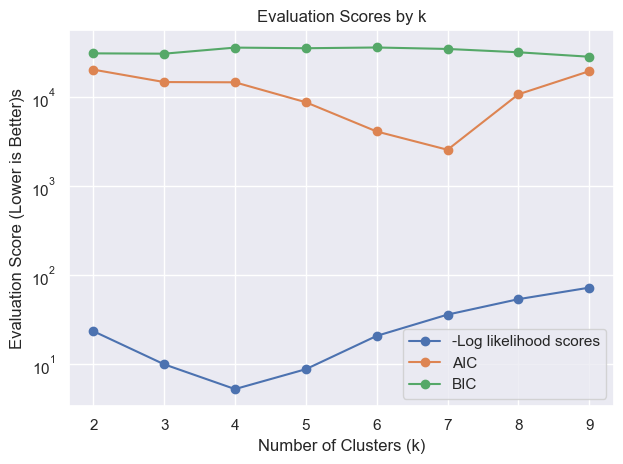

In [7]:
print(f'Scores: {gmm_scores} \n AIC: {gmm_aic} \n BIC: {gmm_bic}')
plt.plot(k_range, np.abs(gmm_scores), label='-Log likelihood scores', marker='o')
plt.plot(k_range, np.abs(gmm_aic), label='AIC', marker='o')
plt.plot(k_range, gmm_bic, label='BIC', marker='o')
plt.semilogy()
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Evaluation Score (Lower is Better)s')
plt.title('Evaluation Scores by k')
plt.legend()

plt.tight_layout()
plt.savefig('Evaluation_Scores.png')
plt.show()

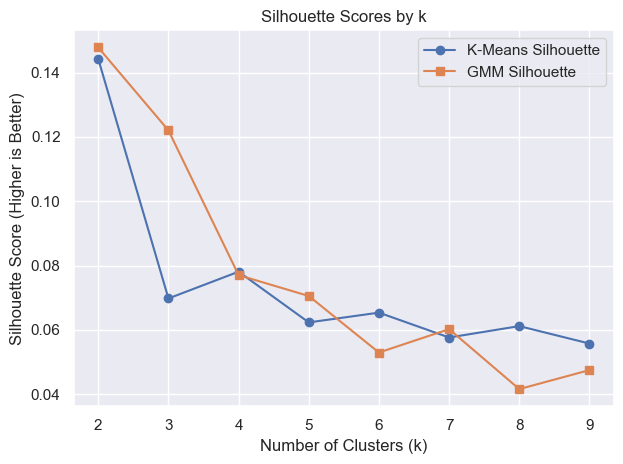

In [8]:
plt.plot(k_range, kmeans_silhouette_scores, label='K-Means Silhouette', marker='o')
plt.plot(k_range, gmm_silhouette_scores, label='GMM Silhouette', marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (Higher is Better)')
plt.title('Silhouette Scores by k')
plt.legend()

plt.tight_layout()
# plt.savefig('cluster_evaluation.png')
plt.show()

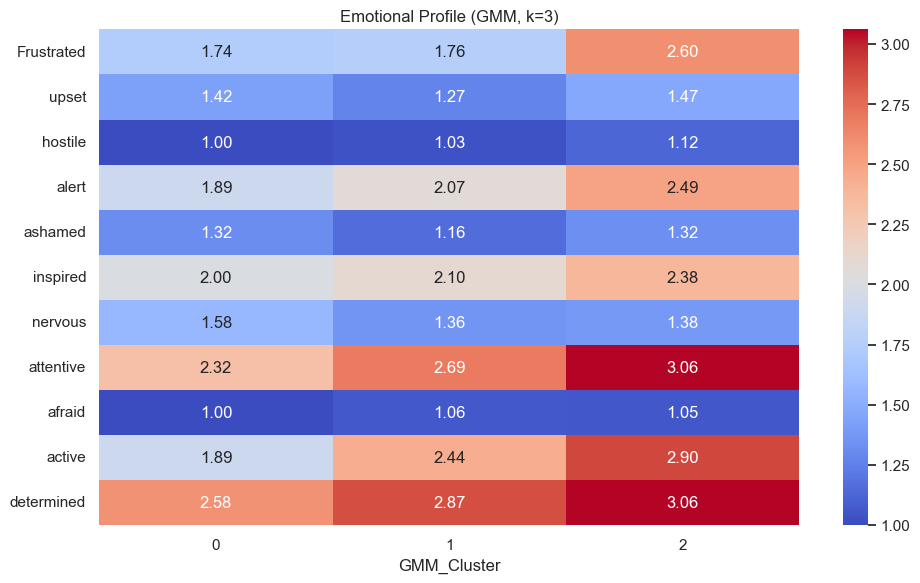

In [29]:
# Choose K, for GMM, see profiles for emotional states in clusters!
_K = 3

emotion_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
Y_analysis = Y.copy()
Y_analysis['GMM_Cluster'] = gmm_labels[_K - 2]
cluster_profiles = Y_analysis.groupby('GMM_Cluster')[emotion_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Emotional Profile (GMM, k={_K})')
plt.tight_layout()
plt.savefig(f'cluster_emotional_profiles_{_K}.png')
plt.show()

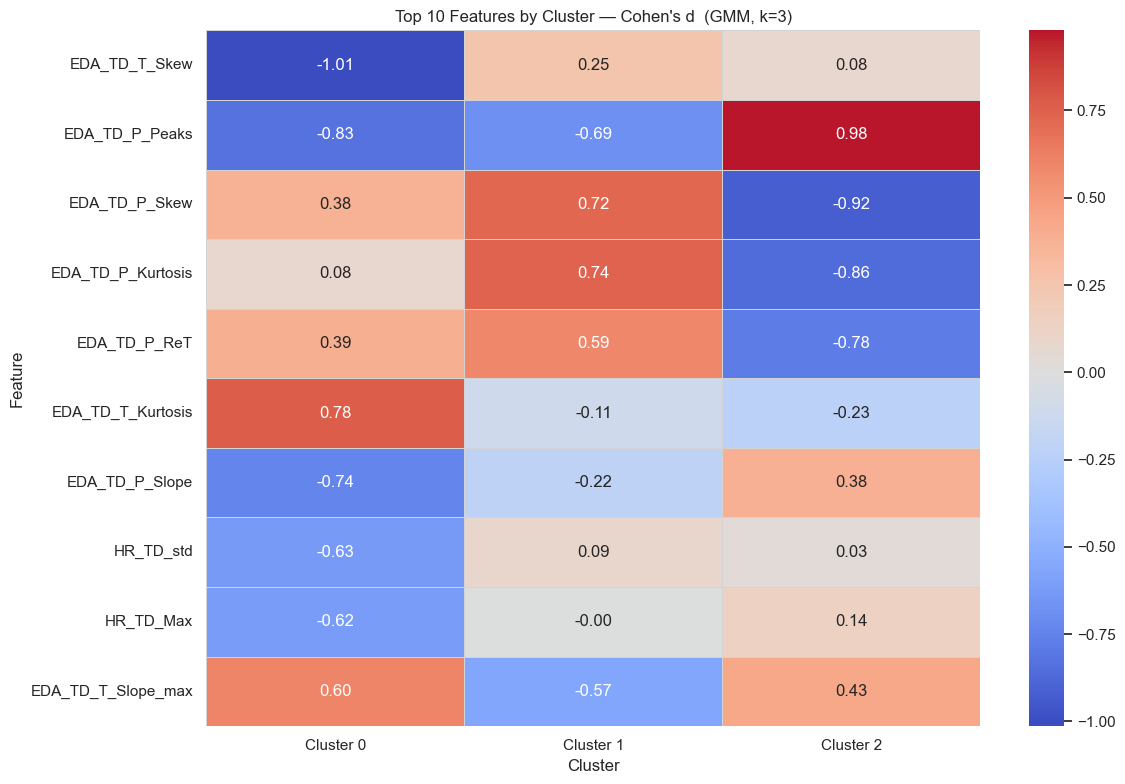

In [30]:
def cohens_d_per_cluster(X, labels, feature_names):
    n_clusters = len(np.unique(labels))
    importance = np.zeros((n_clusters, X.shape[1]))

    for k in range(n_clusters):
        mask = labels == k
        in_cluster  = X[mask]
        out_cluster = X[~mask]

        mean_diff = in_cluster.mean(axis=0) - out_cluster.mean(axis=0)
        # Pooled std
        pooled_std = np.sqrt(
            (in_cluster.std(axis=0)**2 + out_cluster.std(axis=0)**2) / 2
        )
        importance[k] = mean_diff / (pooled_std + 1e-9)

    return importance

importance_matrix = cohens_d_per_cluster(X, gmm_labels[_K - 2], X.columns.tolist())


# Top features for cluster k:
k = 1

top_idx = np.argsort(np.abs(importance_matrix[k]))[::-1][:10]
def plot_cluster_importance(X, labels, feature_names, _K, top_n=10, figsize=(12, 8)):
    unique_clusters = np.arange(_K)
    importance = np.zeros((_K, X.shape[1]))
    means = np.zeros((_K, X.shape[1]))

    for k in unique_clusters:
        mask        = labels == k
        in_cluster  = X[mask]
        out_cluster = X[~mask]

        means[k] = in_cluster.mean(axis=0)

        mean_diff  = in_cluster.mean(axis=0) - out_cluster.mean(axis=0)
        pooled_std = np.sqrt(
            (in_cluster.std(axis=0) ** 2 + out_cluster.std(axis=0) ** 2) / 2
        )
        importance[k] = mean_diff / (pooled_std + 1e-9)

    # --- Filter to top_n most distinctive features ---
    max_abs_d = np.abs(importance).max(axis=0)      # worst-case across all clusters
    top_idx   = np.argsort(max_abs_d)[::-1][:top_n] # top_n highest
    #top_idx   = np.sort(top_idx)                     # restore original feature order

    importance_df = pd.DataFrame(
        importance[:, top_idx].T,
        index=np.array(feature_names)[top_idx],
        columns=[f"Cluster {k}" for k in unique_clusters]
    )
    means_df = pd.DataFrame(
        means[:, top_idx].T,
        index=np.array(feature_names)[top_idx],
        columns=[f"Cluster {k}" for k in unique_clusters]
    )

    plt.figure(figsize=figsize)
    sns.heatmap(
        importance_df,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        center=0,
        linewidths=0.4,
        linecolor="lightgrey"
    )
    plt.title(f"Top {top_n} Features by Cluster — Cohen's d  (GMM, k={_K})")
    plt.xlabel("Cluster")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f'cluster_top_{top_n}_important_features_K_{_K}.png')
    plt.show()

    return importance_df

feature_names = X.columns.tolist()
importance_df = plot_cluster_importance(X, gmm_labels[_K - 2], feature_names, _K=_K)